<a href="https://colab.research.google.com/github/priyanka22wh1a1264/DataAnalysis/blob/main/Loan_Approval_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Analysis In Loan Dataset

In [111]:
#import neccesary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.metrics import confusion_matrix,classification_report


In [112]:
#load the data
df=pd.read_csv("/content/loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


EDA

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [114]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [115]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [116]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [117]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [118]:
df["person_age"].unique()
df=df[df["person_age"]<=100]


In [119]:
df["previous_loan_defaults_on_file"].unique()

array(['No', 'Yes'], dtype=object)

<Axes: xlabel='loan_status', ylabel='Count'>

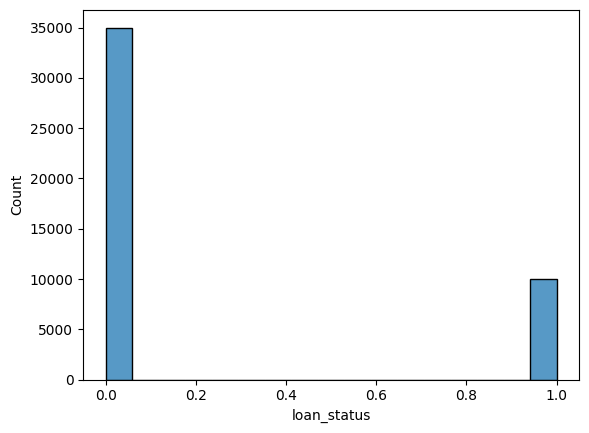

In [120]:
sns.histplot(x="loan_status",data=df)

The dataset contains most of the values which are failed to approve the loan

<Axes: xlabel='person_gender', ylabel='count'>

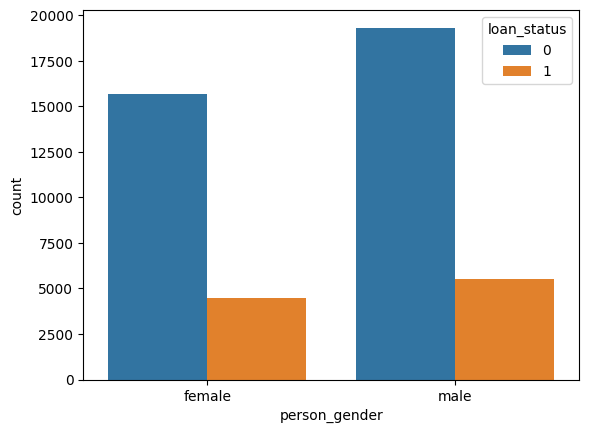

In [121]:
sns.countplot(x="person_gender",data=df,hue="loan_status")

male are getting more loans than females

<Axes: xlabel='person_age', ylabel='Count'>

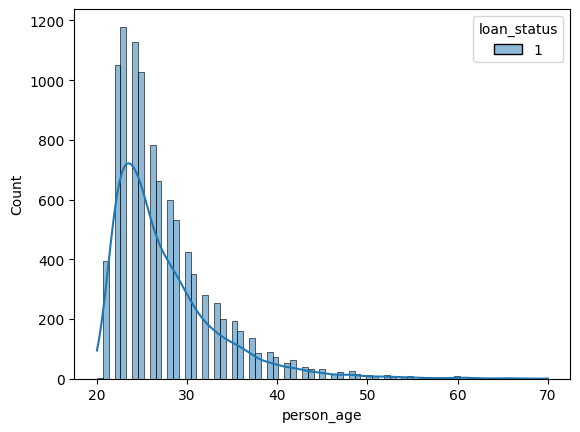

In [122]:
sns.histplot(x="person_age",data=df[df["loan_status"]==1],hue="loan_status",kde=True)

most of the people between 20 to 30 age are getting the loans



<Axes: xlabel='person_education', ylabel='count'>

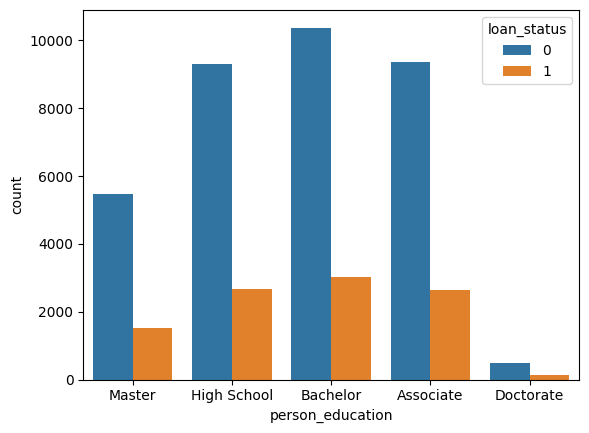

In [123]:
sns.countplot(x="person_education",data=df,hue="loan_status")

the people who have educational degree as bachelor are getting more loans

In [124]:
df.groupby("loan_status")["person_income"].mean()


,person_income
loan_status,
0,85630.263567
1,59886.096900


if we have lesser income also person may get loan

In [125]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


<Axes: xlabel='credit_score', ylabel='Count'>

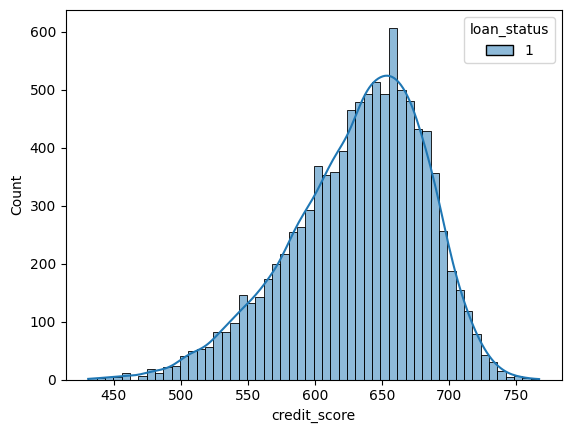

In [127]:
sns.histplot(x="credit_score",data=df[df["loan_status"]==1],kde=True,hue="loan_status")

the people who are having credit score between 600 to 700 are getting loans appproved

<Axes: >

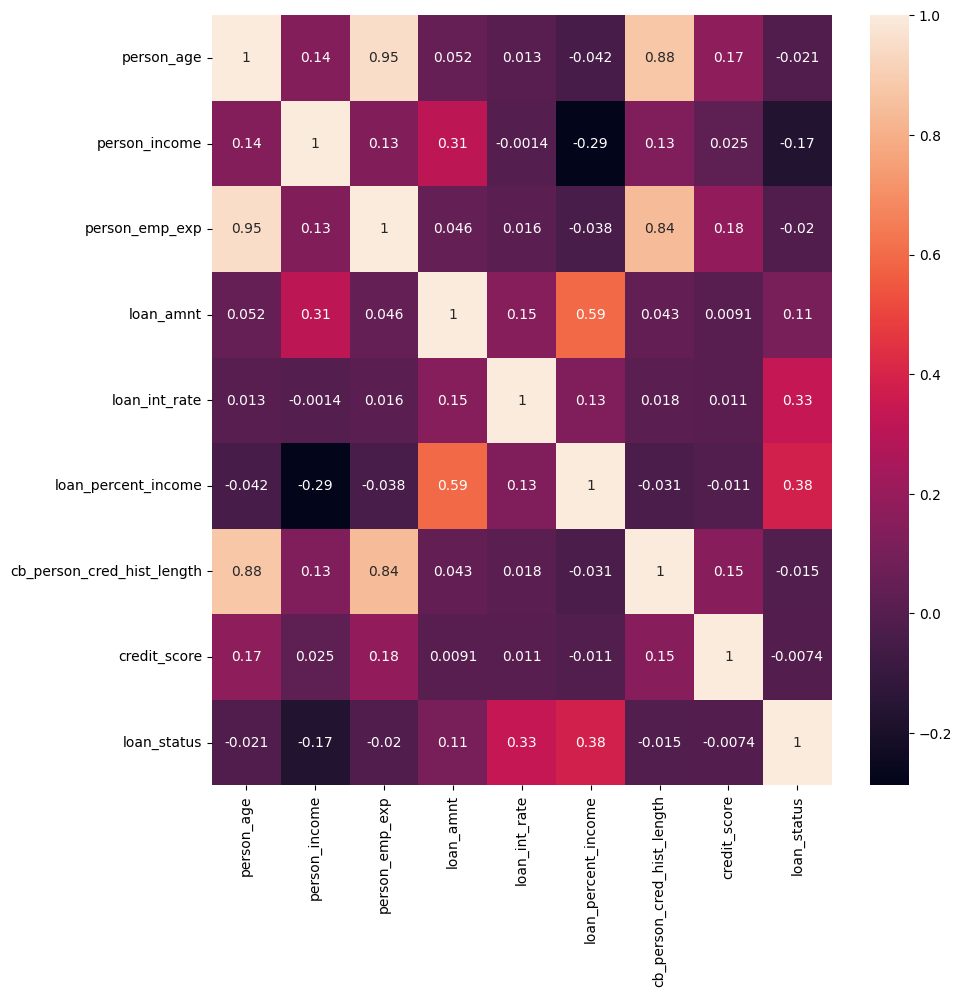

In [128]:
newcol=[col for col in df.columns if df[col].dtype!=object]
data=df[newcol].corr()
plt.figure(figsize=(10,10))
sns.heatmap(data,annot=True)


In [129]:
#changing categorical cols into numerical
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["person_education"]=le.fit_transform(df["person_education"])
df["person_gender"]=le.fit_transform(df["person_gender"])
df['person_home_ownership']=le.fit_transform(df['person_home_ownership'])
df['loan_intent']=le.fit_transform(df['loan_intent'])
df['previous_loan_defaults_on_file']=le.fit_transform(df['previous_loan_defaults_on_file'])

#Model Training

In [130]:
#divide data into i/p and o/p
x=df.drop("loan_status",axis=1)
y=df["loan_status"]
y

,loan_status
0,1
1,0
2,1
3,1
4,1
...,...
44995,1
44996,1
44997,1
44998,1


In [132]:
#split data into training and testing data
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)

In [134]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
xtrain=sc.fit_transform(xtrain)
xtest=sc.transform(xtest)

In [135]:
#Model training
model=SVC()
model.fit(xtrain,ytrain)

SVC()

#Model Evaluation and Tuning

In [136]:
ypred=model.predict(xtest)
ypred

array([1, 0, 0, ..., 1, 0, 1])

In [137]:
confusion_matrix(ytest,ypred)

array([[10044,   446],
       [  792,  2216]])

In [138]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94     10490
           1       0.83      0.74      0.78      3008

    accuracy                           0.91     13498
   macro avg       0.88      0.85      0.86     13498
weighted avg       0.91      0.91      0.91     13498



In [139]:
print("training eff",model.score(xtrain,ytrain))
print("testing eff",model.score(xtest,ytest))

training eff 0.9132560723924432
testing eff 0.9082827085494147


It is a generalized model

In [145]:
#new input prediction
newdata=df.iloc[0:1,:-1]
newdata=sc.transform(newdata)
pred=model.predict(newdata)
print(pred)
if pred==0:
  print("loan not approved ")
else:
  print("loan approved")

[1]
loan approved
